# Using TextVectorization in a Sentiment Analysis Model

In [1]:
import pandas as pd

df = pd.read_csv("Data/reviews.csv", encoding="ISO-8859-1")
df = df.sample(frac=1, random_state=0)
df.head()

,Text,Sentiment
11841,Al Pacino was once an actor capable of making ...,0
19602,After Chaplin made one of his best films: Doug...,0
45519,This movie is sort of a Carrie meets Heavy Met...,1
25747,I have fond memories of watching this visually...,1
42642,"In the '70s, Charlton Heston starred in sci-fi...",1


In [4]:
df = df.drop_duplicates()
df.groupby("Sentiment").describe()

Text                                                            \
           count unique                                                top   
Sentiment                                                                    
0          24697  24697  Al Pacino was once an actor capable of making ...   
1          24884  24884  This movie is sort of a Carrie meets Heavy Met...   

                
          freq  
Sentiment       
0            1  
1            1

In [5]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Dense,
    Embedding,
    Flatten,
    InputLayer,
    TextVectorization,
)
from tensorflow.keras.models import Sequential

max_words = 20000
max_length = 500

model = Sequential()
model.add(InputLayer(input_shape=(1,), dtype=tf.string))
model.add(TextVectorization(max_tokens=max_words, output_sequence_length=max_length))
model.add(Embedding(max_words, 32, input_length=max_length))
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dense(1, activation="sigmoid"))
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization (TextVe  (None, 500)               0         
 ctorization)                                                    
                                                                 
 embedding (Embedding)       (None, 500, 32)           640000    
                                                                 
 flatten (Flatten)           (None, 16000)             0         
                                                                 
 dense (Dense)               (None, 128)               2048128   
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                                 
Total params: 2688257 (10.25 MB)
Trainable params: 2688257 (10.25 MB)
Non-trainable params: 0 (0.00 Byte)
________________

In [6]:
X = df["Text"]
y = df["Sentiment"]

model.layers[0].adapt(X)

In [7]:
hist = model.fit(X, y, validation_split=0.5, epochs=5, batch_size=250)

Epoch 1/5
100/100 [==============================] - 3s 26ms/step - loss: 0.5986 - accuracy: 0.6566 - val_loss: 0.3424 - val_accuracy: 0.8551
Epoch 2/5
100/100 [==============================] - 3s 27ms/step - loss: 0.2166 - accuracy: 0.9164 - val_loss: 0.2922 - val_accuracy: 0.8804
Epoch 3/5
100/100 [==============================] - 3s 27ms/step - loss: 0.0572 - accuracy: 0.9852 - val_loss: 0.3498 - val_accuracy: 0.8723
Epoch 4/5
100/100 [==============================] - 3s 28ms/step - loss: 0.0111 - accuracy: 0.9989 - val_loss: 0.3950 - val_accuracy: 0.8766
Epoch 5/5
100/100 [==============================] - 3s 27ms/step - loss: 0.0030 - accuracy: 0.9998 - val_loss: 0.4322 - val_accuracy: 0.8762


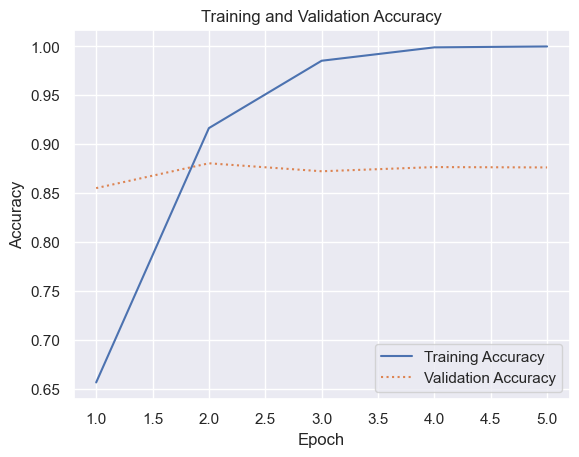

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()


acc = hist.history["accuracy"]
val_acc = hist.history["val_accuracy"]
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, "-", label="Training Accuracy")
plt.plot(epochs, val_acc, ":", label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right");

In [9]:
text = "Excellent food and fantastic service!"
model.predict([text])[0][0]

1/1 [==============================] - 0s 53ms/step


0.9880158

In [10]:
text = "The long lines and poor customer service really turned me off"
model.predict([text])[0][0]

1/1 [==============================] - 0s 19ms/step


0.04603114